# **Imports**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

df = pd.read_csv("archive/vgsales.csv")


# **Data Exploration**

Mean, median, std

In [3]:
print("Shape: ", df.shape)
print(df.dtypes)
print(df.isna().sum())

mean_sales = df['Global_Sales'].mean()
median_sales = df['Global_Sales'].median()
std_sales = df['Global_Sales'].std()

print(mean_sales, median_sales, std_sales)

Shape:  (16598, 11)
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
0.5374406555006628 0.17 1.5550279355699124


Top 10

In [4]:
top10 = df.sort_values(by='Global_Sales', ascending=False).head(10)
print(top10[['Name', 'Platform', 'Global_Sales']])

                        Name Platform  Global_Sales
0                 Wii Sports      Wii         82.74
1          Super Mario Bros.      NES         40.24
2             Mario Kart Wii      Wii         35.82
3          Wii Sports Resort      Wii         33.00
4   Pokemon Red/Pokemon Blue       GB         31.37
5                     Tetris       GB         30.26
6      New Super Mario Bros.       DS         30.01
7                   Wii Play      Wii         29.02
8  New Super Mario Bros. Wii      Wii         28.62
9                  Duck Hunt      NES         28.31


Sales histogram

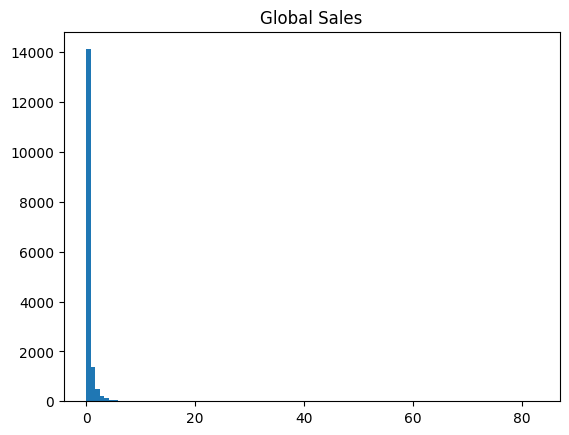

In [5]:
plt.figure()
plt.hist(df['Global_Sales'], bins = 100)
plt.title("Global Sales")
plt.show()

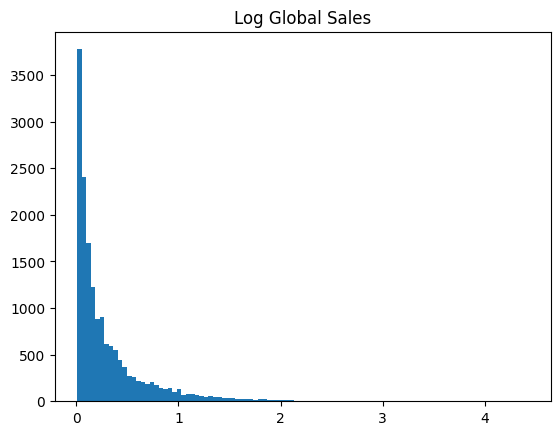

In [6]:
plt.figure()
plt.hist(np.log1p(df['Global_Sales']), bins = 100)
plt.title('Log Global Sales')
plt.show()

Sales per platform

In [7]:
platform_sales = df.groupby('Platform')['Global_Sales'].mean().sort_values(ascending=False)
print(platform_sales.head(10))

Platform
GB      2.606633
NES     2.561939
GEN     1.050370
SNES    0.837029
PS4     0.827679
X360    0.774672
2600    0.729925
PS3     0.720722
Wii     0.699404
N64     0.686144
Name: Global_Sales, dtype: float64


Top 5 genres

In [8]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print(genre_sales.head(5))

Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Name: Global_Sales, dtype: float64


Region distribution

In [9]:
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
region_share = df[regions].sum()/ df['Global_Sales'].sum()
print(region_share)

NA_Sales       0.492459
EU_Sales       0.272871
JP_Sales       0.144726
Other_Sales    0.089429
dtype: float64


Time trends

In [10]:
games_per_year = df.groupby('Year').size()
avg_sales_year = df.groupby('Year')['Global_Sales'].mean()
platform_year = df.groupby(['Year', 'Platform']).size().unstack(fill_value=0)

print(games_per_year)
print(avg_sales_year)
print(platform_year)

Year
1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      60
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     349
2001.0     482
2002.0     829
2003.0     775
2004.0     763
2005.0     941
2006.0    1008
2007.0    1202
2008.0    1428
2009.0    1431
2010.0    1259
2011.0    1139
2012.0     657
2013.0     546
2014.0     582
2015.0     614
2016.0     344
2017.0       3
2020.0       1
dtype: int64
Year
1980.0    1.264444
1981.0    0.777609
1982.0    0.801667
1983.0    0.987647
1984.0    3.597143
1985.0    3.852857
1986.0    1.765238
1987.0    1.358750
1988.0    3.148000
1989.0    4.320588
1990.0    3.086875
1991.0    0.786098
1992.0    1.771163
1993.0    0.766333
1994.0    0.654298
1995.0    0.402329
1996.0    0.757224
1997.0    0.695433
1998.0    0.676702
1999.0    0.743402
2000.0    0.

Correlations

In [11]:
corr = df[regions + ['Global_Sales']].corr()
print(corr)

              NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
NA_Sales      1.000000  0.767727  0.449787     0.634737      0.941047
EU_Sales      0.767727  1.000000  0.435584     0.726385      0.902836
JP_Sales      0.449787  0.435584  1.000000     0.290186      0.611816
Other_Sales   0.634737  0.726385  0.290186     1.000000      0.748331
Global_Sales  0.941047  0.902836  0.611816     0.748331      1.000000


In [12]:
rank_corr = df['Rank'].corr(df['Global_Sales'])
print(rank_corr)

-0.4274066079886817


Long tail

In [13]:
sorted_sales = df.sort_values(by='Global_Sales', ascending=False)
cum_sales = sorted_sales['Global_Sales'].cumsum()
share = cum_sales / cum_sales.iloc[-1]
percent_games = (share <= 0.8).mean()
print(percent_games)

0.2521388119050488


Top publishers

In [14]:
publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)
print(publisher_sales.head(10))

Publisher
Nintendo                        1786.56
Electronic Arts                 1110.32
Activision                       727.46
Sony Computer Entertainment      607.50
Ubisoft                          474.72
Take-Two Interactive             399.54
THQ                              340.77
Konami Digital Entertainment     283.64
Sega                             272.99
Namco Bandai Games               254.09
Name: Global_Sales, dtype: float64


Publishers specialization

In [15]:
publisher_genre = df.groupby(['Publisher', 'Genre']).size().unstack(fill_value=0)
print(publisher_genre)

Genre                         Action  Adventure  Fighting  Misc  Platform  \
Publisher                                                                   
10TACLE Studios                    0          1         0     0         0   
1C Company                         0          0         0     0         0   
20th Century Fox Video Games       4          0         0     0         0   
2D Boy                             0          0         0     0         0   
3DO                               17          3         1     0         1   
...                              ...        ...       ...   ...       ...   
id Software                        0          0         0     0         0   
imageepoch Inc.                    0          1         0     0         0   
inXile Entertainment               0          0         0     0         0   
mixi, Inc                          1          0         0     0         0   
responDESIGN                       0          0         0     0         0   

# **Preprocessing**

Missing values

In [16]:
df['Publisher'] = df['Publisher'].fillna('Unknown')
df['Genre'] = df['Genre'].fillna('Unknown')
df = df.dropna(subset=['Year'])

Year

In [17]:
df['Year'] = df['Year'].astype(int)

New features

In [18]:
df['Share_USA'] = df['NA_Sales'] / (df['Global_Sales'] + 1e-9)
df['Share_EU'] = df['EU_Sales'] / (df['Global_Sales'] + 1e-9)
df['Share_JP'] = df['JP_Sales'] / (df['Global_Sales'] + 1e-9)
df['Share_Other'] = df['Other_Sales'] / (df['Global_Sales'] + 1e-9)

Outliers

In [19]:
threshold = df['Global_Sales'].quantile(0.99)
df_no_outliers = df[df['Global_Sales'] <= threshold]

Encoding and normalization (mentioned later)

In [20]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

PCA

In [21]:
from sklearn.decomposition import PCA

X_regions = df[regions]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_regions)

Grouping rare publishers

In [22]:
publisher_counts = df['Publisher'].value_counts()
rare_publishers = publisher_counts[publisher_counts < 50].index

df['Publisher_Grouped'] = df['Publisher'].replace(rare_publishers, 'Other')

Feature selection

In [23]:
from sklearn.ensemble import RandomForestRegressor

X = df[['Year']]
y = df['Global_Sales']

rf = RandomForestRegressor().fit(X, y)

# **Problem Definition**

Regression

In [24]:
X = df[['Year']]
y = np.log1p(df['Global_Sales'])

Classification

In [25]:
q = df['Global_Sales'].quantile([0.25, 0.5, 0.75])

def label_sales(x):
    if x <= q[0.25]: return 'flop'
    elif x <= q[0.5]: return 'medium'
    elif x <= q[0.75]: return 'hit'
    else: return 'mega_hit'

df['Sales_Class'] = df['Global_Sales'].apply(label_sales)

Binary hit

In [26]:
df['Hit'] = (df['Global_Sales'] > 1.0).astype(int)

Top 10%

In [27]:
threshold_top10 = df ['Global_Sales'].quantile(0.9)
df['Top10'] = (df['Global_Sales'] >= threshold_top10).astype(int)

# **Models**

Baseline

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

X = df[['Year']]
y = np.log1p(df['Global_Sales'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
pred = lr.predict(X_test)
rmse = mean_squared_error(y_test, pred)
print(rmse)

0.16498715574284725


Random forest

In [31]:
from sklearn.ensemble import RandomForestRegressor 

rf = RandomForestRegressor(n_estimators = 300, random_state= 42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print(mean_squared_error(y_test, pred))

0.16137674356594495


Gradient Boosting

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor().fit(X_train, y_train)
pred = gb.predict(X_test)
print(mean_squared_error(y_test, pred))

0.16137103255826085


KNN

In [33]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5).fit(X_train, y_train)
pred = knn.predict(X_test)
print(mean_squared_error(y_test, pred))

0.1879562605564578


Cross-validation

In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='neg_root_mean_squared_error')
print(-scores.mean())

0.3718812468499001


Time-based split

In [36]:
train = df[df['Year'] < 2015]
test = df[df['Year'] >= 2015]

Leakage check:
adding NA_Sales as feature makes result innaturally good

# **Feature Engineering**

Decade, platform popularity, genre popularity, publisher strength, competition, regional preference

In [37]:
df['Decade'] = (df['Year'] // 10) * 10
platform_popularity = df.groupby(['Year', 'Platform'])['Global_Sales'].mean()
genre_popularity = df.groupby('Genre')['Global_Sales'].mean()

publisher_strength = df.groupby('Publisher')['Global_Sales'].mean()
df['Publisher_Strength'] = df['Publisher'].map(publisher_strength)

competition = df.groupby('Year').size()
df['Competition'] = df['Year'].map(competition)

genre_region = df.groupby('Genre')[regions].mean()

NLP in names

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=100)
X_title = vectorizer.fit_transform(df['Name'])

Simple target encoding

In [ ]:
target_encoding = df.groupby('Platform')['Global_Sales'].mean()
df['Platform_TE'] = df['Platform'].map(target_encoding)

# **Models interpretation**

In [39]:
importances = rf.feature_importances_
print(importances)

[1.]


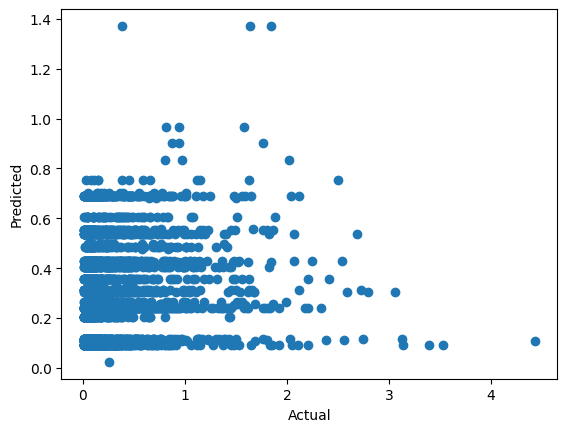

In [40]:
plt.scatter(y_test, pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

 97%|=================== | 3181/3266 [00:27<00:00]       

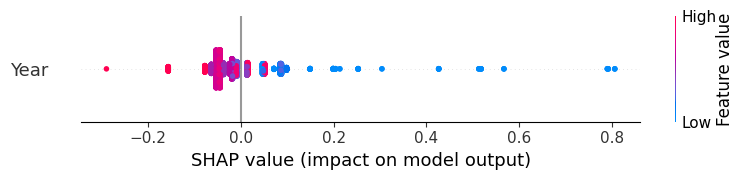

In [41]:
import shap 

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values)

In [42]:
errors = np.abs(y_test - pred)
worst = errors.sort_values(ascending = False).head(10)
print(worst)

0     4.319808
3     3.435588
8     3.297677
14    3.044722
15    3.012217
19    2.748798
31    2.634412
27    2.485019
46    2.443033
33    2.412823
Name: Global_Sales, dtype: float64


In [43]:
error_df = X_test.copy()
error_df['error'] = errors.values
error_df['Platform'] = df.loc[X_test.index, 'Platform']
print(error_df.groupby('Platform')['error'].mean())

Platform
2600    0.251117
3DS     0.330346
DC      0.329968
DS      0.224929
GB      0.557152
GBA     0.211259
GC      0.229795
GEN     0.411677
N64     0.425989
NES     0.293115
NG      0.130939
PC      0.311861
PS      0.266295
PS2     0.250059
PS3     0.364096
PS4     0.277929
PSP     0.262884
PSV     0.293823
SAT     0.180055
SNES    0.316119
WS      0.014455
Wii     0.327975
WiiU    0.337218
X360    0.369925
XB      0.238396
XOne    0.364269
Name: error, dtype: float64


In [44]:
sample = X_test.iloc[0].copy()
print('Original prediction: ', rf.predict([sample]))

Original prediction:  [0.27699779]


d:\sickens\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
